In [76]:
import numpy as np
import matplotlib.pyplot as plt
import sinter

In [77]:
tasks = sinter.stats_from_csv_files("/home/fidel/Projects/corrqec2/data/experiment1.csv")

In [70]:
int(tasks[0].json_metadata['experiment_args']['rounds'][0])

3

In [81]:
def calc_xi(a, b):
    return - 1 / np.log(1 - a - b)

def xi_to_Delta(xi):
    return 1 - np.exp(-1/xi)

def Delta_to_xi(Delta):
    return -1 / np.log(1 - Delta)

def calc_per_round(per_shot: float, rounds: int):        
    return 0.5 * (1 - (1 - 2 * per_shot) ** (1/rounds))


distances = [5, 7, 9, 11, 13]
xis = [2, 4, 6, 8, 12, 16, 24]
results_dict = {distance: {xi: None for xi in xis} for distance in distances}

for task in tasks:
    
    distance = task.json_metadata['experiment_args']['distance']
    model_params = task.json_metadata['noise_model_args']['model_params']
    rounds_mult = int(task.json_metadata['experiment_args']['rounds'][0])
    n_rounds = distance * rounds_mult
    a, b = model_params['a'], model_params['b']
    xi = int(np.round(calc_xi(a, b)))
    shots = task.shots
    errors = task.errors
    per_shot = errors / shots
    per_round = calc_per_round(per_shot, n_rounds)
    results_dict[distance][xi] = per_round
    # print(f"Distance: {distance}, xi: {xi}")

/tmp/ipykernel_216290/2194663156.py:8: RuntimeWarning: divide by zero encountered in divide
  return -1 / np.log(1 - Delta)


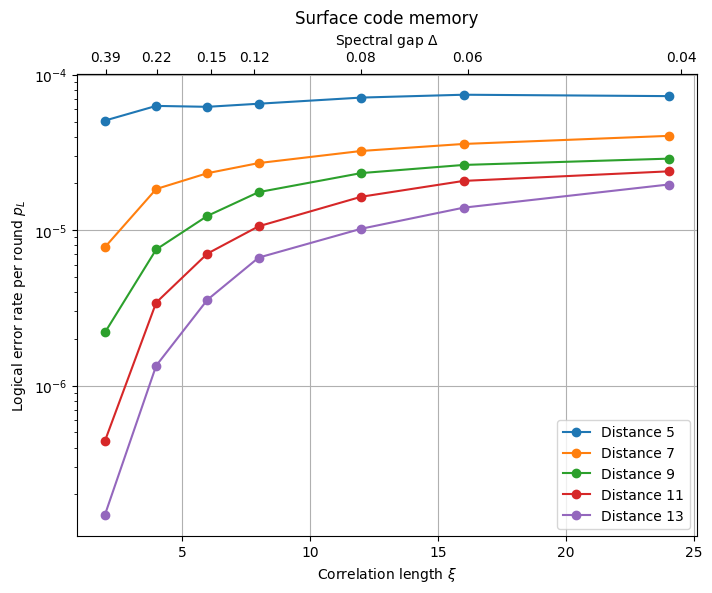

In [114]:
fig, ax = plt.subplots(figsize=(8, 6))
for distance in distances:
    xi_values = sorted(results_dict[distance].keys())
    logical_error_rates = [results_dict[distance][xi] for xi in xi_values]
    ax.plot(xi_values, logical_error_rates, marker='o', label=f'Distance {distance}')
ax.semilogy()
ax.grid(True)
ax.set_xlabel('Correlation length $\\xi$')
ax.set_ylabel('Logical error rate per round $p_{L}$')
ax.set_title('Surface code memory')
secax = ax.secondary_xaxis('top', functions=(xi_to_Delta, Delta_to_xi))
# secax.set_xscale('log')
secax.set_xlabel('Spectral gap $\\Delta$')
delta_ticks = [np.round(xi_to_Delta(xi), 2) for xi in xi_values]
secax.set_xticks(delta_ticks)

ax.legend()

In [119]:
from pathlib import Path
save_dir = Path.home() / "mx95_scratch2" / "jkam" / "corrqec2_results"
output_path = save_dir / "experiment1.csv"

In [120]:
output_path.with_suffix(".resume.csv")

PosixPath('/home/fidel/mx95_scratch2/jkam/corrqec2_results/experiment1.resume.csv')